In [2]:
from pathlib import Path
import sys
import os
import re

PROJECT_ROOT = Path.cwd().parent

import pandas as pd
import csv

import src.constants as Con


In [3]:
from src.data_paths import (
    TEST_RUN_PATH,
    NEW_EXP_OUT_DIR,
    SECOND_TEST_PATH,
    SECOND_TEST_OUT_DIR,
)


## Pick the raw run and convert its reports

Two experiment runs were exported in different formats, so the notebook takes the
raw folder as a switch and normalizes both onto the same `csvs/` layout:

| run | folder | files | format |
|---|---|---|---|
| `testrun_QA` | `data_raw/testrun_QA` | `IA_answers.xls`, `fixations_answers.xls`, `messages_answers.xls` | tab-separated, UTF-16 |
| `second_test` | `data_raw/second_test` | `A_IA.tsv`, `A_fixations.tsv` | tab-separated, UTF-8 (BOM) |

Set `RUN_NAME` below to choose which one everything downstream loads from — the
converted CSVs, the cleaned CSVs, and the processed pipeline output all follow it
(each run writes to its own folder under `data/`, so they don't overwrite each other).

`second_test` has no messages report; nothing downstream reads it, so it is simply
skipped when absent.

In [4]:
# Which raw run to process: "second_test" (.tsv) or "testrun_QA" (.xls).
RUN_NAME = "second_test"

RAW_RUNS = {
    "testrun_QA": (TEST_RUN_PATH, NEW_EXP_OUT_DIR),
    "second_test": (SECOND_TEST_PATH, SECOND_TEST_OUT_DIR),
}
RAW_RUN_PATH, RUN_OUT_DIR = RAW_RUNS[RUN_NAME]

# Converted CSVs live next to the raw reports, in the same layout for either run.
NEW_OUT_PATH = RAW_RUN_PATH / "csvs"
NEW_OUT_PATH.mkdir(parents=True, exist_ok=True)

print(f"run:  {RUN_NAME}")
print(f"raw:  {RAW_RUN_PATH}")
print(f"csvs: {NEW_OUT_PATH}")
print(f"out:  {RUN_OUT_DIR}")


run:  second_test
raw:  E:\Technion\QA PROJECT\programming\QA_eyetracking_workspace\data_raw\second_test
csvs: E:\Technion\QA PROJECT\programming\QA_eyetracking_workspace\data_raw\second_test\csvs
out:  E:\Technion\QA PROJECT\programming\QA_eyetracking_workspace\data\second_test_runs


In [5]:
# Both export formats are plain tab-separated text; only the extension, the
# encoding and the file naming differ, so one reader covers them.
RAW_REPORT_ENCODINGS = {
    ".xls": "utf-16",   # testrun_QA DataViewer export
    ".tsv": "utf-8-sig",  # second_test DataViewer export (UTF-8 with BOM)
    ".csv": "utf-8-sig",
}


def read_raw_report(path: Path) -> pd.DataFrame:
    """Read one raw DataViewer report (.xls / .tsv / .csv) into a DataFrame.

    Quoting is disabled because the reports carry bare quote characters inside
    the stimulus text. The UTF-16 .xls exports need the python parser; the
    UTF-8 .tsv ones go through the (much faster) C parser.
    """
    encoding = RAW_REPORT_ENCODINGS[path.suffix.lower()]
    kwargs = dict(encoding=encoding, sep="	", quoting=csv.QUOTE_NONE)
    if encoding == "utf-16":
        kwargs["engine"] = "python"
    else:
        kwargs["low_memory"] = False
    return pd.read_csv(path, **kwargs)


def canonical_report_name(path: Path) -> str:
    """Map a raw report filename onto the canonical CSV name the pipeline reads.

    testrun_QA already uses the canonical names (`IA_answers.xls`, ...), while
    second_test prefixes them with the report letter (`A_IA.tsv`,
    `A_fixations.tsv`); both normalize onto `<report>_answers.csv`.
    """
    tokens = re.split(r"[_\-\s]+", path.stem.lower())
    if any(t.startswith("fixation") for t in tokens):
        return "fixations_answers.csv"
    if any(t.startswith("message") or t == "msg" for t in tokens):
        return "messages_answers.csv"
    if "ia" in tokens:
        return "IA_answers.csv"
    return path.with_suffix(".csv").name


RAW_REPORT_PATTERNS = ("*.xls", "*.tsv")

raw_reports = sorted(
    p for pattern in RAW_REPORT_PATTERNS for p in RAW_RUN_PATH.glob(pattern)
)
if not raw_reports:
    raise FileNotFoundError(
        f"no {' / '.join(RAW_REPORT_PATTERNS)} reports found in {RAW_RUN_PATH}"
    )

for raw_path in raw_reports:                      # source: the run's raw folder
    df = read_raw_report(raw_path)
    csv_path = NEW_OUT_PATH / canonical_report_name(raw_path)   # dest: csvs/
    df.to_csv(csv_path, index=False, encoding="utf-8")
    print(f"{raw_path.name}: {df.shape} -> {csv_path.name}")


A_fixations.tsv: (7421, 319) -> fixations_answers.csv
A_IA.tsv: (14068, 335) -> IA_answers.csv


In [6]:
ia_df = pd.read_csv(NEW_OUT_PATH / "IA_answers.csv", low_memory=False)
fix_df = pd.read_csv(NEW_OUT_PATH / "fixations_answers.csv", low_memory=False)

# second_test has no messages report, and nothing downstream reads one anyway.
_msg_path = NEW_OUT_PATH / "messages_answers.csv"
msg_df = pd.read_csv(_msg_path, low_memory=False) if _msg_path.exists() else None

print(f"ia_df:  {ia_df.shape}")
print(f"fix_df: {fix_df.shape}")
print(f"msg_df: {'(no messages report)' if msg_df is None else msg_df.shape}")
print(f"participants: {sorted(ia_df[Con.RECORDING_SESSION_LABEL].unique())}")


ia_df:  (14068, 335)
fix_df: (7421, 319)
msg_df: (no messages report)
participants: ['Y7_12_b3', 'r1_l1_b1', 'r2_l7_b1', 'r3_l7_b2', 'r4_l16_2', 'r5_l9_b3', 'r6_12_b3']


## Standardize new-data column names for the pipeline

The new experiment reports use different column names/indexing than the pipeline
expects. Rename them (data name → pipeline name), convert the numeric `answers_order`
to letters, lowercase `participant_id`, and write cleaned CSVs to `csvs/cleaned/`,
which the pipeline then reads:

| new data | pipeline expects |
|---|---|
| `RECORDING_SESSION_LABEL` | `participant_id` |
| `onestopqa_question_id` | `same_critical_span` |
| `practice` | `practice_trial` |
| `correct_answer` (0–3) | `correct_answer_position` |
| `FINAL_ANSWER` (0–3) | `selected_answer_position` |
| `answer_0..answer_3` (0-indexed) | `answer_1..answer_4` (1-indexed) |
| `answer_a..answer_d` | `answer_A..answer_D` |
| `answers_order` = `[2,1,0,3]` (screen→answer index) | `['C','B','A','D']` (letter per screen pos) |

Notes:
- `answer_A..D` are supplied directly, so the base feature that would recompute them
  (`add_answer_text_columns`) is excluded from the run.
- The new experiment has no repeated-reading trials (`repeated_reading_trial` column
  absent), so `remove_repeats` is turned off in the run below.
- `participant_id` is lowercased so it stays consistent everywhere — the button-click
  join also lowercases it, and the last-label / RT merges match on it.

In [7]:
import ast

# Rename map: new-data column (left) -> pipeline column (right).
NEW_DATA_RENAME_MAP = {
    Con.RECORDING_SESSION_LABEL: Con.PARTICIPANT_ID,        # -> participant_id
    "onestopqa_question_id": Con.SAME_CRITICAL_SPAN_COLUMN,  # -> same_critical_span
    "practice": Con.PRACTICE_TRIAL_COLUMN,                   # -> practice_trial
    "correct_answer": Con.CORRECT_ANSWER_POSITION_COLUMN,    # -> correct_answer_position (0-3)
    "FINAL_ANSWER": Con.SELECTED_ANSWER_POSITION_COLUMN,     # -> selected_answer_position (0-3)
    # answers are 0-indexed (answer_0..answer_3); shift up one to the 1-indexed
    # answer_1..answer_4 the pipeline reads (this drops the old answer_0 name).
    f"{Con.ANSWER_PREFIX}0": f"{Con.ANSWER_PREFIX}1",
    f"{Con.ANSWER_PREFIX}1": f"{Con.ANSWER_PREFIX}2",
    f"{Con.ANSWER_PREFIX}2": f"{Con.ANSWER_PREFIX}3",
    f"{Con.ANSWER_PREFIX}3": f"{Con.ANSWER_PREFIX}4",
    # answer_a..answer_d already hold the labelled options; capitalize the letter
    # to the answer_A..answer_D the pipeline uses. Because these are supplied
    # directly, add_answer_text_columns (which would recompute them) is excluded
    # from the run below.
    f"{Con.ANSWER_PREFIX}a": f"{Con.ANSWER_PREFIX}A",
    f"{Con.ANSWER_PREFIX}b": f"{Con.ANSWER_PREFIX}B",
    f"{Con.ANSWER_PREFIX}c": f"{Con.ANSWER_PREFIX}C",
    f"{Con.ANSWER_PREFIX}d": f"{Con.ANSWER_PREFIX}D",
}


def _answers_order_to_letters(value):
    """Convert the new-data numeric answers_order to the letter form the pipeline reads.

    build_exp_inputs.py builds answers_order as screen_position -> original answer
    index (0=A, 1=B, 2=C, 3=D), e.g. [2, 1, 0, 3]. The pipeline expects the *letter*
    at each screen position, e.g. ['C', 'B', 'A', 'D']. Values already in letter form
    are left untouched.
    """
    order = ast.literal_eval(value) if isinstance(value, str) else value
    return [
        Con.ANSWER_LABELS[int(x)] if str(x).lstrip("-").isdigit() else x
        for x in order
    ]


def standardize_new_data_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Rename new-experiment columns to the names the pipeline expects, convert the
    numeric answers_order to letters, and lowercase participant_id.

    Renames are applied in a single pass (so the answer 0->1, 1->2, ... shift
    doesn't collide); columns not present are left untouched. participant_id is
    lowercased here so it stays consistent everywhere downstream (the button-click
    join also lowercases it, and the last-label / RT merges match on it).
    """
    df = df.rename(columns=NEW_DATA_RENAME_MAP)
    if Con.ANSWERS_ORDER_COLUMN in df.columns:
        df[Con.ANSWERS_ORDER_COLUMN] = df[Con.ANSWERS_ORDER_COLUMN].apply(
            _answers_order_to_letters
        )
    if Con.PARTICIPANT_ID in df.columns:
        df[Con.PARTICIPANT_ID] = df[Con.PARTICIPANT_ID].astype(str).str.strip().str.lower()
    return df


CLEANED_DIR = NEW_OUT_PATH / "cleaned"
CLEANED_DIR.mkdir(parents=True, exist_ok=True)

for _name in ["IA_answers.csv", "fixations_answers.csv"]:
    _df = pd.read_csv(NEW_OUT_PATH / _name, low_memory=False)
    _df = standardize_new_data_columns(_df)
    _out = CLEANED_DIR / _name
    _df.to_csv(_out, index=False)
    print(f"{_name}: {_df.shape} -> cleaned/{_name}")


IA_answers.csv: (14068, 335) -> cleaned/IA_answers.csv
fixations_answers.csv: (7421, 319) -> cleaned/fixations_answers.csv


## Run the `data_csv_generation` pipeline on the new experiment inputs

Runs `src.data_prep.data_csv_generation.main()` against the cleaned IA + fixations
CSVs of the selected run (`RAW_RUN_PATH / "csvs" / "cleaned"`) and writes the result
to that run's output folder (`RUN_OUT_DIR`, i.e. `data/second_test_runs/` for
`second_test` and `data/new_exp_try_runs/` for `testrun_QA`).

Button clicks are rebuilt from the fixations report itself, so the missing messages
report doesn't matter here.

In [8]:
from src.data_prep import data_csv_generation as dcg

# --- New-experiment inputs (column-standardized CSVs from the cleaning cell) ---
NEW_IA_ANSWERS_PATH = CLEANED_DIR / "IA_answers.csv"
NEW_FIX_ANSWERS_PATH = CLEANED_DIR / "fixations_answers.csv"

# --- Where the processed output goes (per selected run, see RUN_NAME above) ---
NEW_EXP_OUT_DIR = RUN_OUT_DIR
NEW_EXP_OUT_PATH = NEW_EXP_OUT_DIR / "all_participants.csv"
NEW_EXP_AUX_DIR = NEW_EXP_OUT_DIR / "Auxiliary"

# Base features to skip for the new data. answer_A..D are already supplied by the
# cleaning step (renamed from answer_a..d), so we don't recompute them.
EXCLUDED_BASE_FUNCS = {"add_answer_text_columns"}


def run_new_exp_pipeline(
    ia_answers_path: Path = NEW_IA_ANSWERS_PATH,
    fixations_path: Path = NEW_FIX_ANSWERS_PATH,
    output_path: Path = NEW_EXP_OUT_PATH,
    aux_dir: Path = NEW_EXP_AUX_DIR,
    verbose: bool = True,
):
    """
    Run the data_csv_generation pipeline on the NEW experiment inputs and save the
    result under data/new_exp_try_runs/.

    Runs base + group features, plus the last-label and RT/TFD steps (fed by button
    clicks extracted from the new fixations report). Paragraph-region RT/TFD is off
    since the new experiment has no paragraph-reading screen.
    """
    NEW_EXP_OUT_DIR.mkdir(parents=True, exist_ok=True)
    aux_dir.mkdir(parents=True, exist_ok=True)

    # Run all registered base features except the excluded ones (built from the
    # registry so it stays correct if base features are added/removed).
    base_function_names = [
        name
        for name, entry in dcg.FUNCTION_REGISTRY.items()
        if entry["kind"] == "base" and name not in EXCLUDED_BASE_FUNCS
    ]

    # `fixations_path` is the single canonical fixations report: it feeds both the
    # pupil stats and create_fixation_sequence_tags (group kwargs are forwarded to
    # the feature functions), so all registered group features can run.
    group_function_names = None  # None = all registered group features

    dcg.main(
        ia_answers_path=ia_answers_path,
        output_path=output_path,
        fixations_path=fixations_path,  # feeds pupil stats + fixation-sequence tags
        compute_pupil_stats=True,
        # keep every artifact inside the new-exp folder
        pupil_stats_path=aux_dir / "participant_pupils.csv",
        button_clicks_path=aux_dir / "button_clicks_data.csv",
        last_labels_path=aux_dir / "all_participants_last.csv",
        rt_and_tfd_path=aux_dir / "RT_and_TFD.csv",
        save_auxiliary=True,
        # last-label + RT/TFD features (fed by the button clicks built below)
        add_last=True,
        add_rts=True,
        include_paragraph=False,           # no paragraph-reading screen in new exp
        rebuild_button_clicks=True,
        # button clicks come from the new fixations report itself (self-contained:
        # holds both message-list and fixation columns), not the legacy CSV+TSV.
        button_clicks_fix_csv_path=fixations_path,
        button_clicks_fix_tsv_path=None,               # single source
        button_clicks_msg_participant_col=Con.PARTICIPANT_ID,
        all_answers_is_cumulative=False,               # new ALL_ANSWERS is per-trial
        base_function_names=base_function_names,
        group_function_names=group_function_names,
        # the new experiment has no repeated-reading trials (no repeated_reading_trial
        # column), so the repeat filter is off; practice trials are still removed.
        remove_repeats=False,
        remove_practice=True,
        verbose=verbose,
    )

    if verbose:
        print(f"\n✓ New-exp pipeline output -> {output_path}")
    return output_path


run_new_exp_pipeline()



Building button-click data from raw (forced)…
Loading fix_csv from: E:\Technion\QA PROJECT\programming\QA_eyetracking_workspace\data_raw\second_test\csvs\cleaned\fixations_answers.csv


E:\Technion\QA PROJECT\programming\QA_eyetracking_workspace\src\data_prep\button_clicks_processing.py:463: DtypeWarning: Columns (0: CURRENT_FIX_PRECISION_MEASURE_RMS_S2S, 1: CURRENT_FIX_PRECISION_MEASURE_SD_WINDOW) have mixed types. Specify dtype option on import or set low_memory=False.
  fix_csv = pd.read_csv(fix_csv_path)


No separate fix_tsv: using fix_csv as the single message source
Malformed trial rows: 0
Affected recordings: 0
Rows: 7421 -> 7421
Saved trial_level_df to: E:\Technion\QA PROJECT\programming\QA_eyetracking_workspace\data\second_test_runs\Auxiliary\button_clicks_data.csv
Final shape: (357, 12)

Loading raw answers from: E:\Technion\QA PROJECT\programming\QA_eyetracking_workspace\data_raw\second_test\csvs\cleaned\IA_answers.csv

Resolving processing function lists…

Loading fixations report once from: E:\Technion\QA PROJECT\programming\QA_eyetracking_workspace\data_raw\second_test\csvs\cleaned\fixations_answers.csv


E:\Technion\QA PROJECT\programming\QA_eyetracking_workspace\src\data_prep\data_csv_generation.py:1531: DtypeWarning: Columns (0: CURRENT_FIX_PRECISION_MEASURE_RMS_S2S, 1: CURRENT_FIX_PRECISION_MEASURE_SD_WINDOW) have mixed types. Specify dtype option on import or set low_memory=False.
  fixations_df = pd.read_csv(fixations_path)


Computing participant pupil stats from preloaded fixations
Saving participant pupils features to: E:\Technion\QA PROJECT\programming\QA_eyetracking_workspace\data\second_test_runs\Auxiliary\participant_pupils.csv

Processing all_participants (row-level)…
Running: add_text_id
Running: add_text_id_with_q
Running: add_is_correct
Running: add_IA_screen_location
Running: add_IA_answer_label
Running: add_selected_answer_label
Running: add_zscored_pupil_columns
Running: add_total_answering_RT_normalized
Applying group-level features for all_participants…
Running group feature: create_mean_area_dwell_time
Running group feature: create_mean_area_fix_count
Running group feature: create_mean_first_fix_duration
Running group feature: create_skip_rate
Running group feature: create_dwell_proportions
Running group feature: create_mean_pupil_size_metrics
Running group feature: create_first_encounter_pupil_size
Running group feature: create_last_area_and_location_visited
Running group feature: create_f

WindowsPath('E:/Technion/QA PROJECT/programming/QA_eyetracking_workspace/data/second_test_runs/all_participants.csv')

## Build model-ready features

Turn the processed IA-level data into the one-row-per-trial modeling feature table
via `save_all_features`, writing it into the new-experiment folder (not the default
`L1_based_data`). It can be read back later with `load_all_features`.

In [9]:
from src.predictive_modeling.answer_correctness.model_data import (
    save_all_features,
    load_all_features,
)

# Model-ready features live alongside the processed data, in the new-exp folder.
NEW_EXP_FEATURES_PATH = NEW_EXP_OUT_DIR / "L1_model_ready_all_features.csv"

processed_ia = pd.read_csv(NEW_EXP_OUT_PATH, low_memory=False)
features_df = save_all_features(processed_ia, output_path=NEW_EXP_FEATURES_PATH, verbose=True)

print("target (is_correct) distribution:")
print(features_df[Con.IS_CORRECT_COLUMN].value_counts(dropna=False).to_string())
features_df.head()


Saved 340 trials x 199 cols to E:\Technion\QA PROJECT\programming\QA_eyetracking_workspace\data\second_test_runs\L1_model_ready_all_features.csv
target (is_correct) distribution:
is_correct
1    205
0    135


,participant_id,TRIAL_INDEX,text_id_with_q,is_correct,area_dwell_proportion__answer_A,area_dwell_proportion__answer_B,area_dwell_proportion__answer_C,area_dwell_proportion__answer_D,area_dwell_proportion__question,first_encounter_avg_pupil_size_z__answer_A,...,TimeSinceOffset_pure_distance_furthest,TimeSinceOffset_pure_distance_closest,TimeSinceOffset_normalized_correct,TimeSinceOffset_normalized_wrong_mean,TimeSinceOffset_normalized_contrast,TimeSinceOffset_normalized_distance_furthest,TimeSinceOffset_normalized_distance_closest,ANSWER_PRESS_NUMBER,total_answering_RT,total_answering_RT_normalized
0,r1_l1_b1,2,1_4_Adv_1_0,0,0.140841,0.377058,0.000000,0.427750,0.054351,1.186706,...,2553.0,606.0,101.000000,251.528571,-150.528571,350.285714,101.000000,2,6798,147.782609
1,r1_l1_b1,3,1_4_Adv_2_1,0,0.000000,0.882787,0.000000,0.000000,0.117213,NaN,...,1216.0,0.0,0.000000,40.533333,-40.533333,121.600000,0.000000,1,1542,26.135593
2,r1_l1_b1,4,1_4_Adv_3_2,1,0.379834,0.158534,0.244179,0.178781,0.038672,-0.031596,...,3037.0,1320.0,324.428571,416.138889,-91.710317,560.238095,86.678571,3,6961,217.531250
3,r1_l1_b1,5,1_4_Adv_4_0,0,0.069325,0.220041,0.325153,0.348057,0.037423,1.307775,...,5315.0,851.0,52.000000,401.242647,-349.242647,894.500000,53.352941,3,5891,113.288462
4,r1_l1_b1,6,1_4_Adv_5_1,0,0.232258,0.258824,0.159583,0.312334,0.037002,1.890977,...,3033.0,71.0,155.111111,237.515909,-82.404798,287.788889,28.263889,1,6511,135.645833


## Train on L1, test on the new data

Fit the logistic-regression correctness model on the **entire** L1 feature set
(no train/test split) and evaluate it on the new-experiment features via
`run_cross_dataset_correctness_bundle`. `feature_cols=None` uses the full feature
set; any feature the new data lacks (e.g. paragraph-region RT/TFD) is dropped
automatically. Metrics, confusion, coefficient, and correlation plots all render.

Detected IPython. Loading juliacall extension. See https://juliapy.github.io/PythonCall.jl/stable/compat/#IPython
train (L1): (19436, 217) | test (new): (340, 199)
[cross-dataset] dropping 18 feature(s) absent from the test set: ['RT_pure_outside', 'RT_pure_distractor', 'RT_pure_critical', 'RT_normalized_outside', 'RT_normalized_distractor', 'RT_normalized_critical', 'TFD_pure_outside', 'TFD_pure_distractor', 'TFD_pure_critical', 'TFD_normalized_outside', 'TFD_normalized_distractor', 'TFD_normalized_critical', 'TimeSinceOffset_pure_outside', 'TimeSinceOffset_pure_distractor', 'TimeSinceOffset_pure_critical', 'TimeSinceOffset_normalized_outside', 'TimeSinceOffset_normalized_distractor', 'TimeSinceOffset_normalized_critical']
MODEL: trial_level_log_reg
----------------------------------------------------------------------
Number of test trials: 340
Accuracy: 0.815
Balanced accuracy: 0.789
Positive (correct) trials: 205
Negative (incorrect) trials: 135

Precision / Recall / F1 (per class)

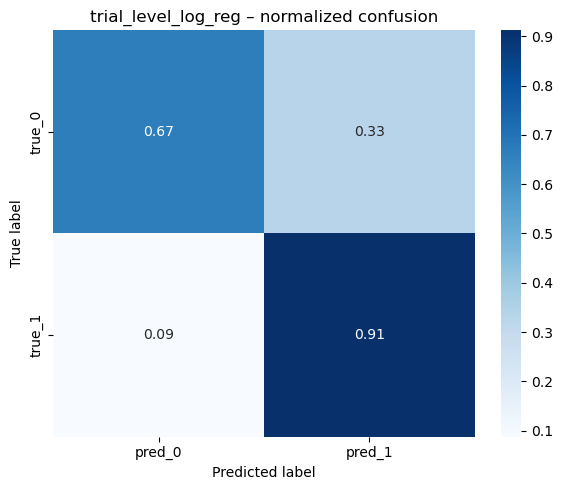

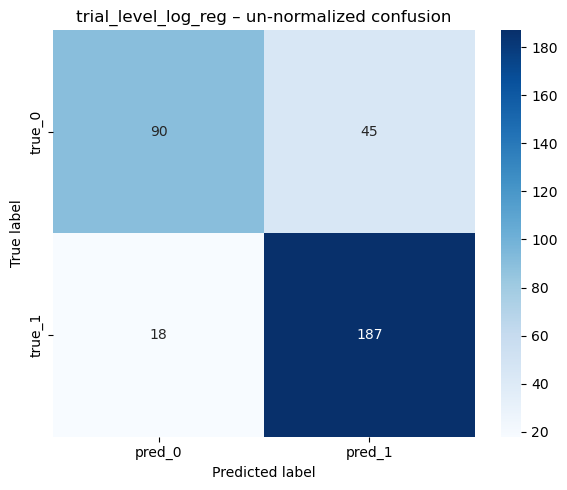

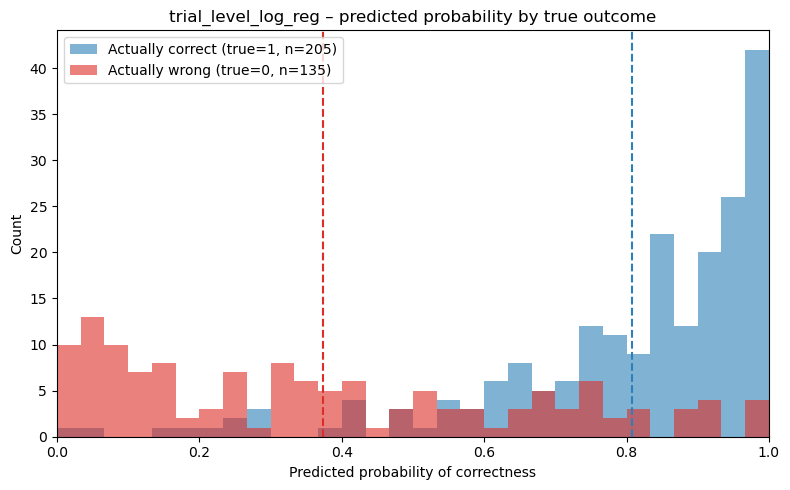

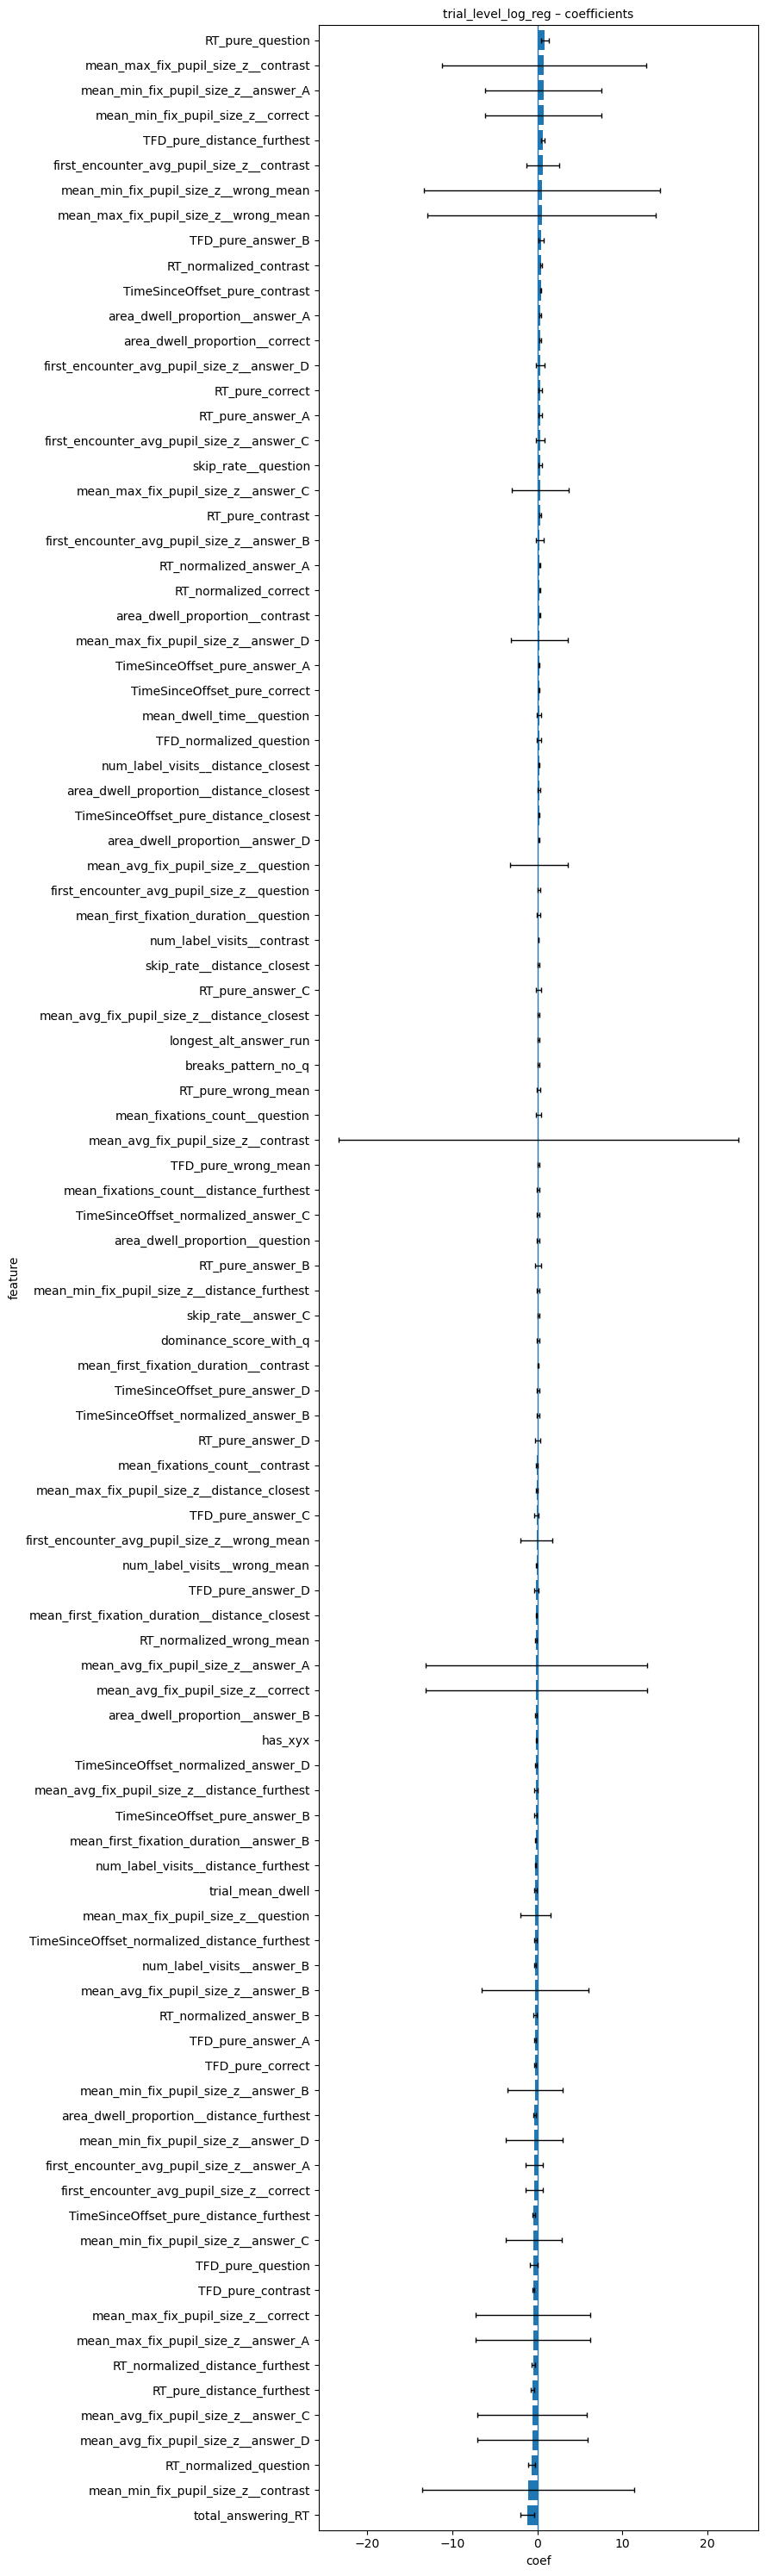

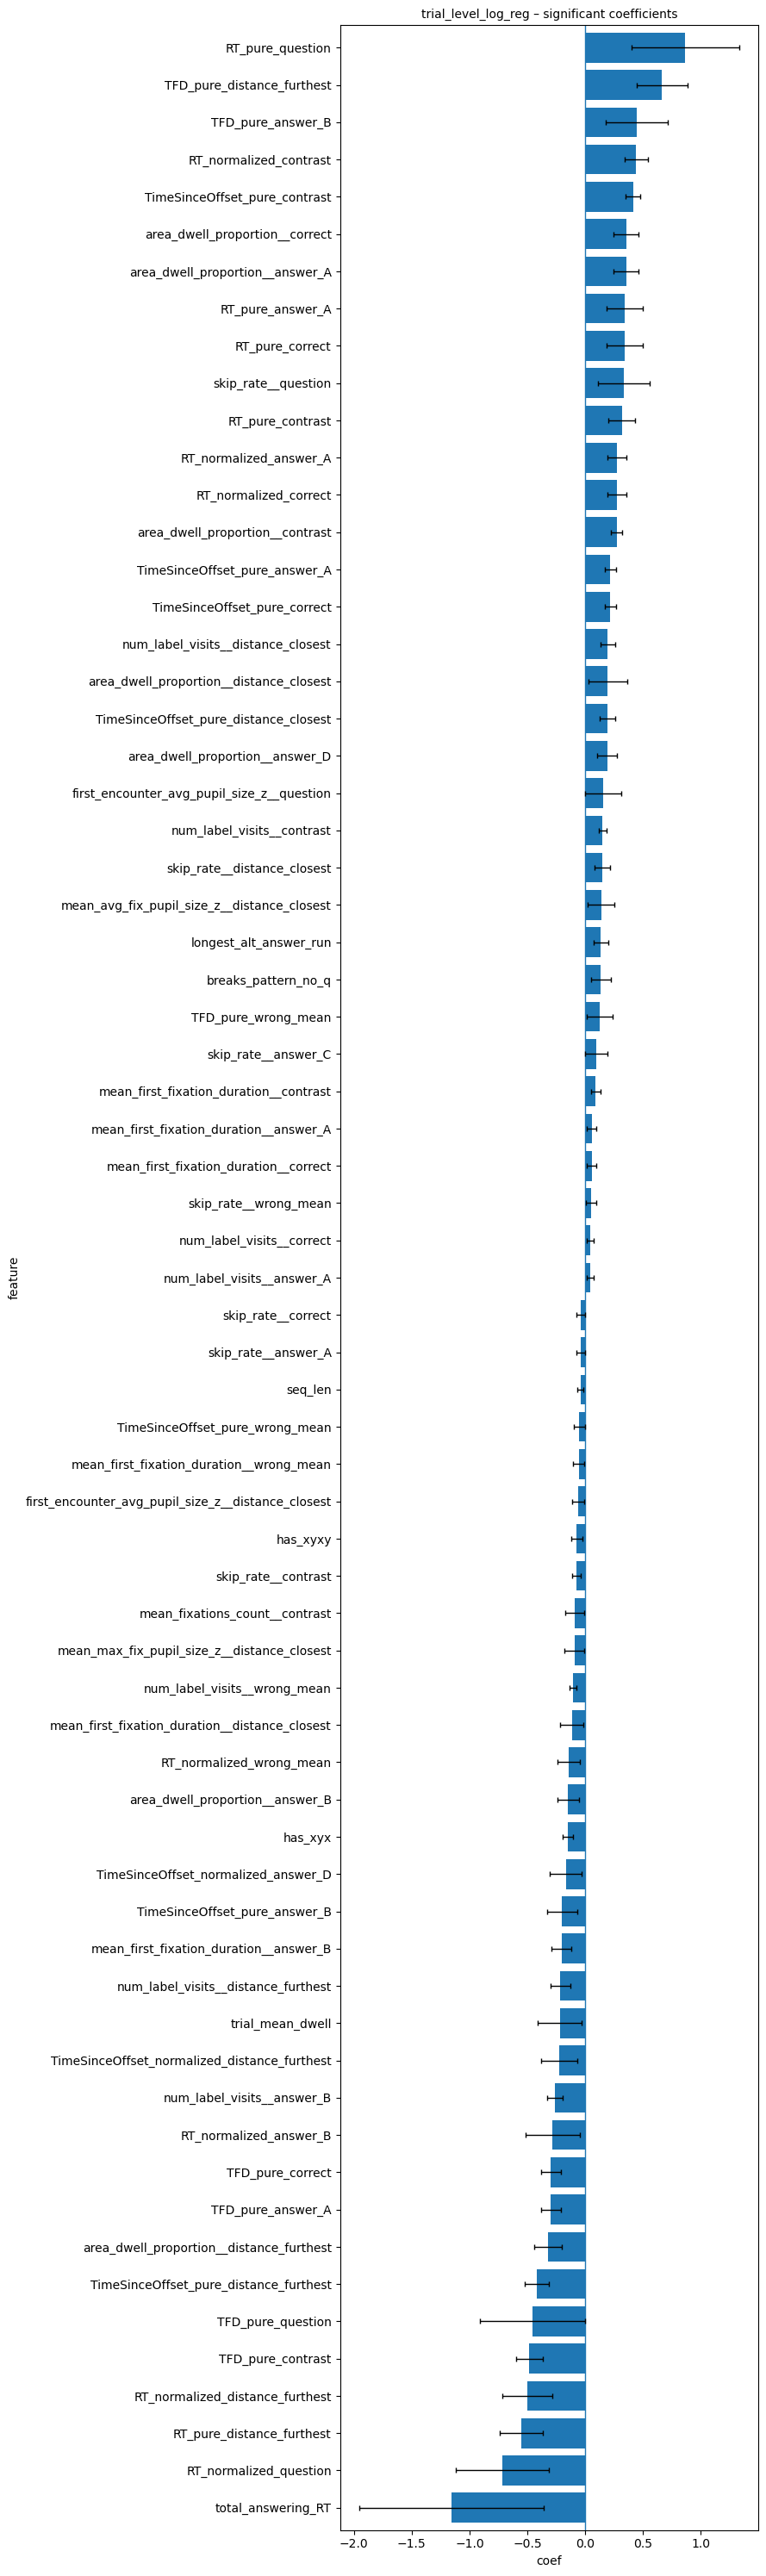

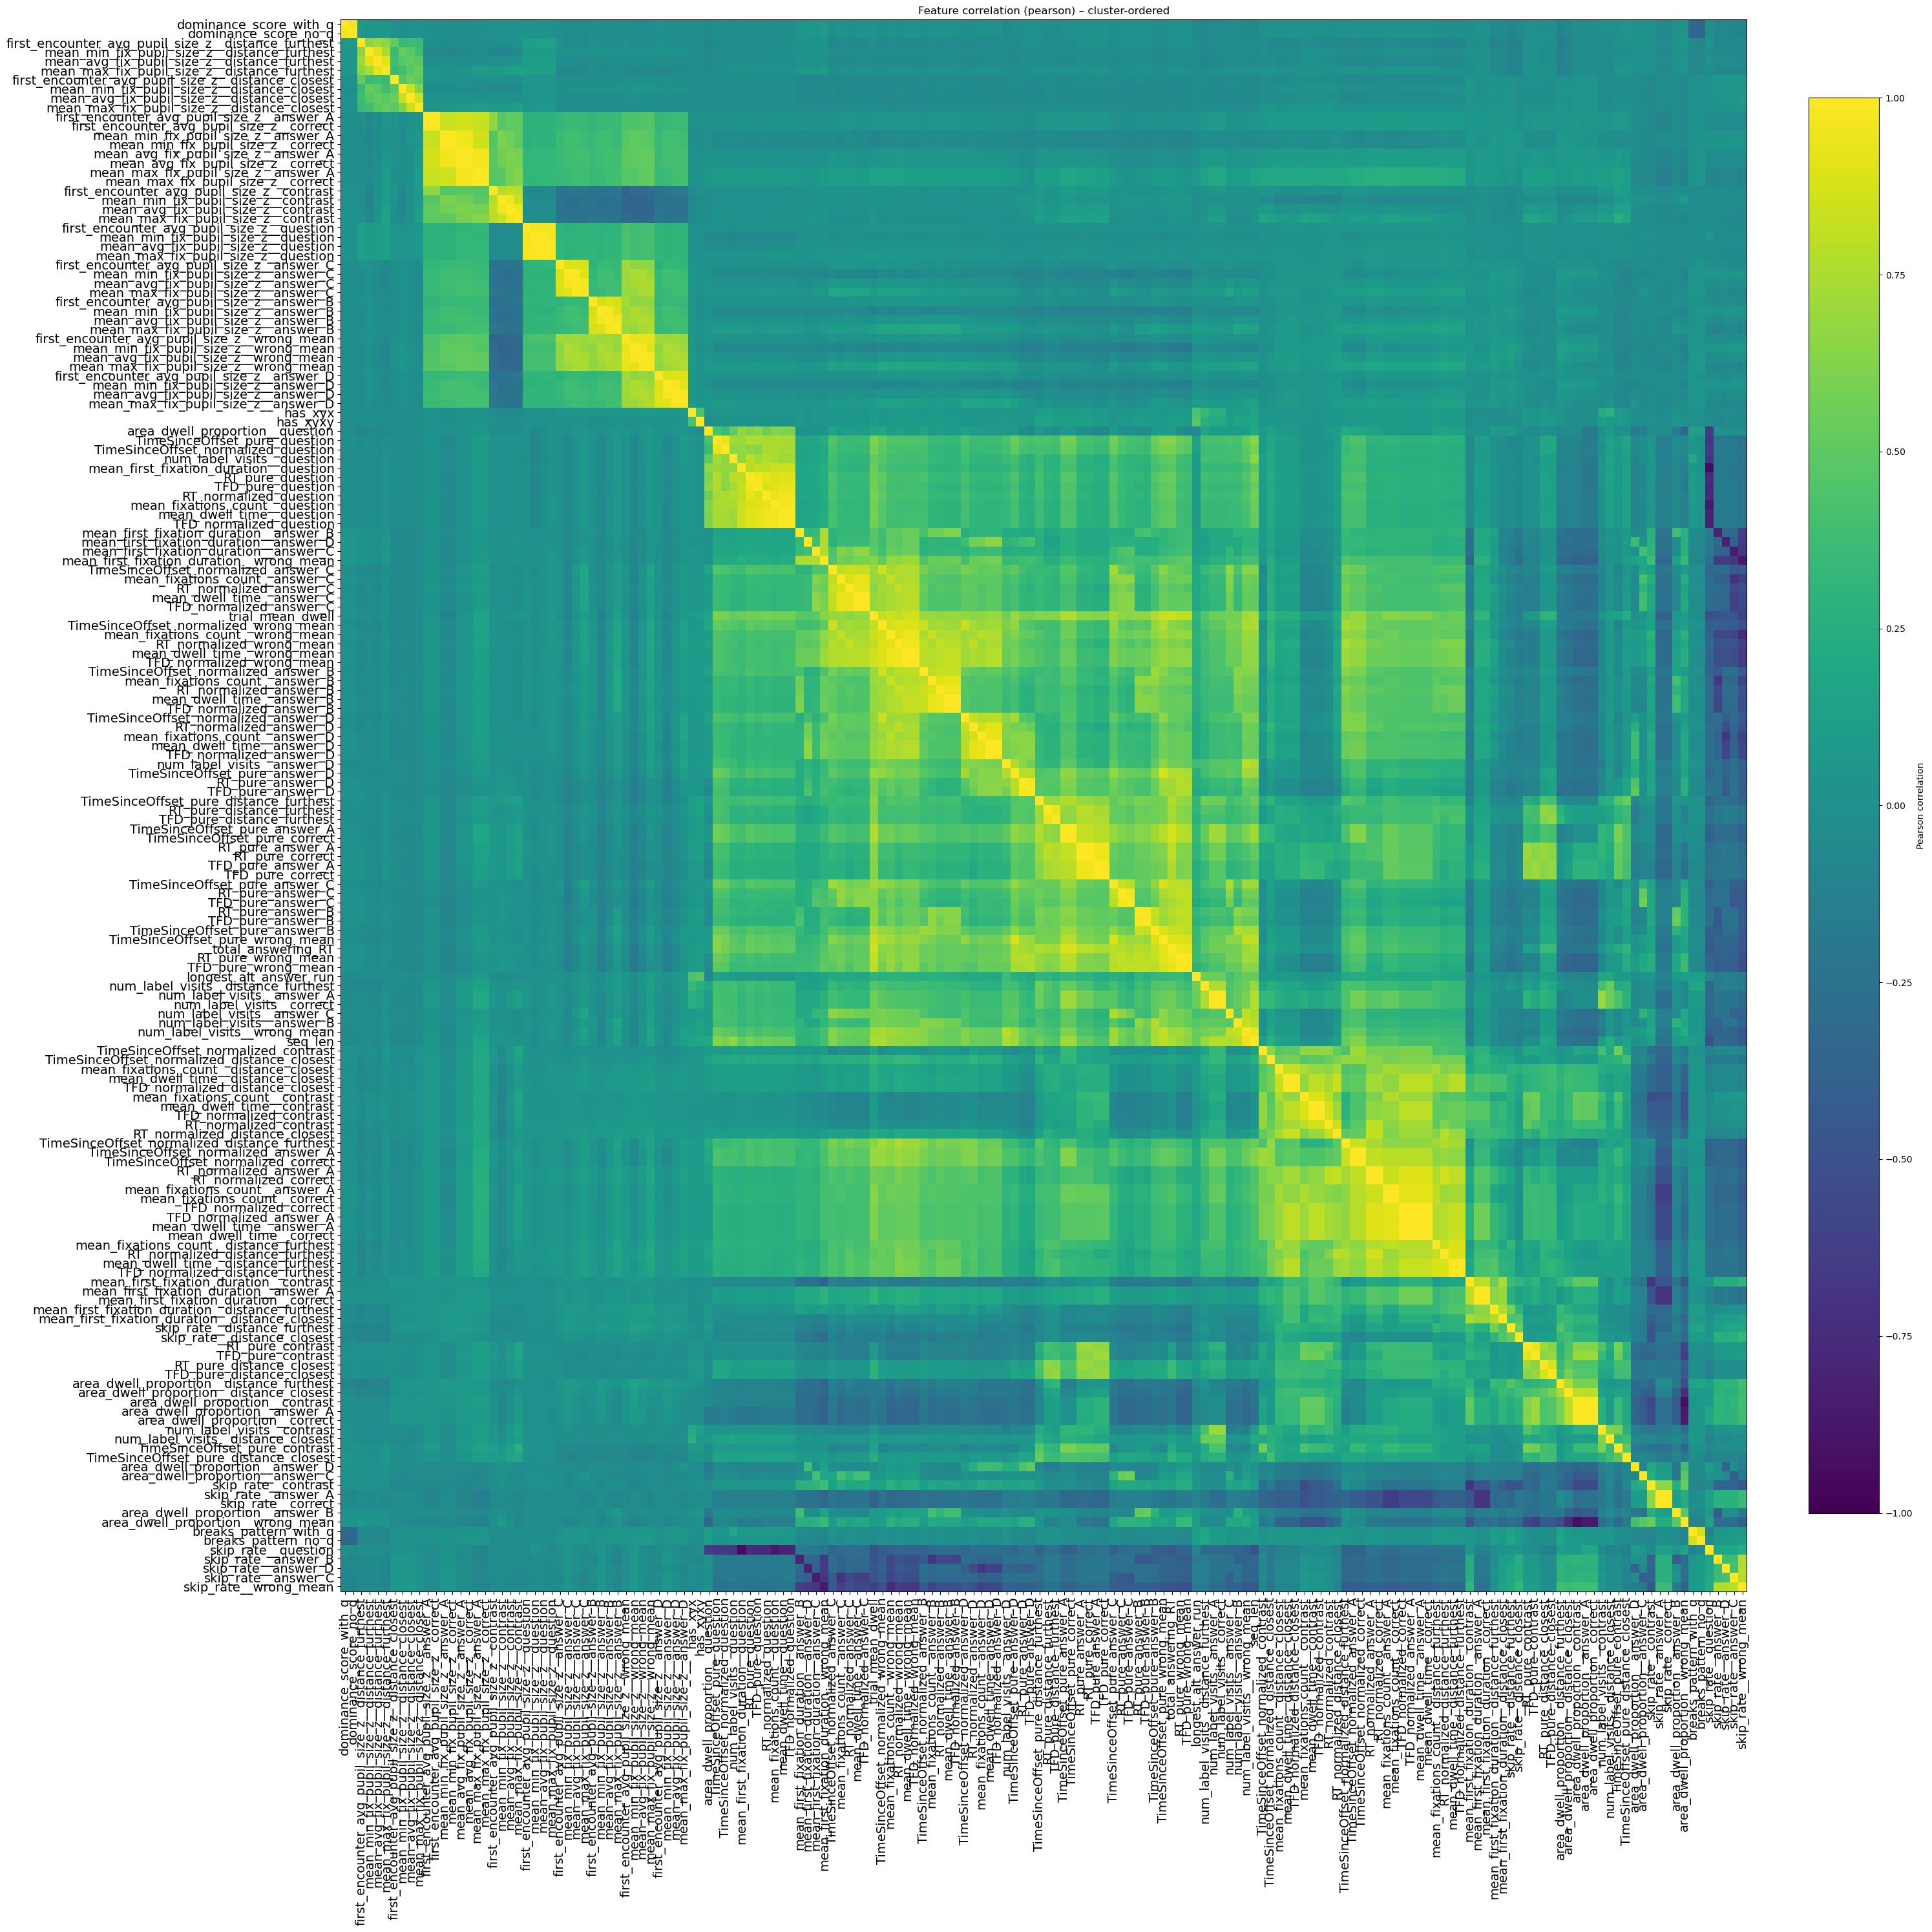

In [10]:
from src.data_paths import READY_ALL_FEATURES_PATH
from src.predictive_modeling.answer_correctness.run_model_bundles import (
    run_cross_dataset_correctness_bundle,
)

# Train on ALL of L1 (no split), test on the new experiment.
l1_features = load_all_features(READY_ALL_FEATURES_PATH)
new_features = load_all_features(NEW_EXP_FEATURES_PATH)
print(f"train (L1): {l1_features.shape} | test (new): {new_features.shape}")

cross_out = run_cross_dataset_correctness_bundle(
    train_df=l1_features,
    test_df=new_features,
    feature_cols=None,   # None = full feature set (features absent from new data are dropped)
    save=False,          # set True to also write plots/CSVs under reports/
    close=False,         # keep figures open so they render in the notebook
)
